<a href="https://colab.research.google.com/github/QuintonPang/mnist-digit-classifier/blob/main/mnist_digit_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# does not work in getting same accuracy for same model, can ignore
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Check if GPU is available (Colab often gives you one for free)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# --- Load MNIST dataset ---
# transforms.ToTensor() converts images from 0-255 pixel values to 0-1 floats
# transforms.Normalize((0.5,), (0.5,)) shifts range from 0-1 to -1 to +1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Image shape:", train_dataset[0][0].shape)

Using device: cuda
Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


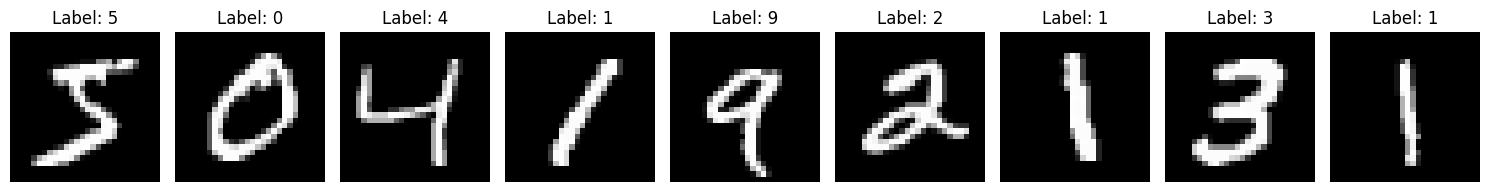

In [2]:
# Look at the first 9 images and their labels
fig, axes = plt.subplots(1, 9, figsize=(15, 3))

for i in range(9):
    image, label = train_dataset[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [3]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),           # [1, 28, 28] → [784]
            nn.Linear(784, 128),    # input layer → hidden layer 1
            nn.ReLU(),              # activation function (non-linearity)
            nn.Linear(128, 64),     # hidden layer 1 → hidden layer 2
            nn.ReLU(),              # activation function again
            nn.Linear(64, 10)       # hidden layer 2 → output (10 classes)
        )

    def forward(self, x):
        return self.network(x)

model = MNISTNet().to(device)
print(model)

MNISTNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train(model, loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in loader:
            # Move data to GPU if available
            images, labels = images.to(device), labels.to(device)

            # Step 1: Zero gradients (clear previous batch's gradients)
            optimizer.zero_grad()

            # Step 2: Forward pass
            outputs = model(images)

            # Step 3: Compute loss
            loss = criterion(outputs, labels)

            # Step 4: Backward pass
            loss.backward()

            # Step 5: Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        accuracy = 100 * correct / total
        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

train(model, train_loader, criterion, optimizer, epochs=5)

Epoch 1/5 — Loss: 0.3905, Accuracy: 88.45%
Epoch 2/5 — Loss: 0.1895, Accuracy: 94.21%
Epoch 3/5 — Loss: 0.1372, Accuracy: 95.76%
Epoch 4/5 — Loss: 0.1106, Accuracy: 96.58%
Epoch 5/5 — Loss: 0.0954, Accuracy: 96.99%


In [5]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(loader)
    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")
    return accuracy

evaluate(model, test_loader, criterion)

Test Loss: 0.1044, Test Accuracy: 96.77%


96.77

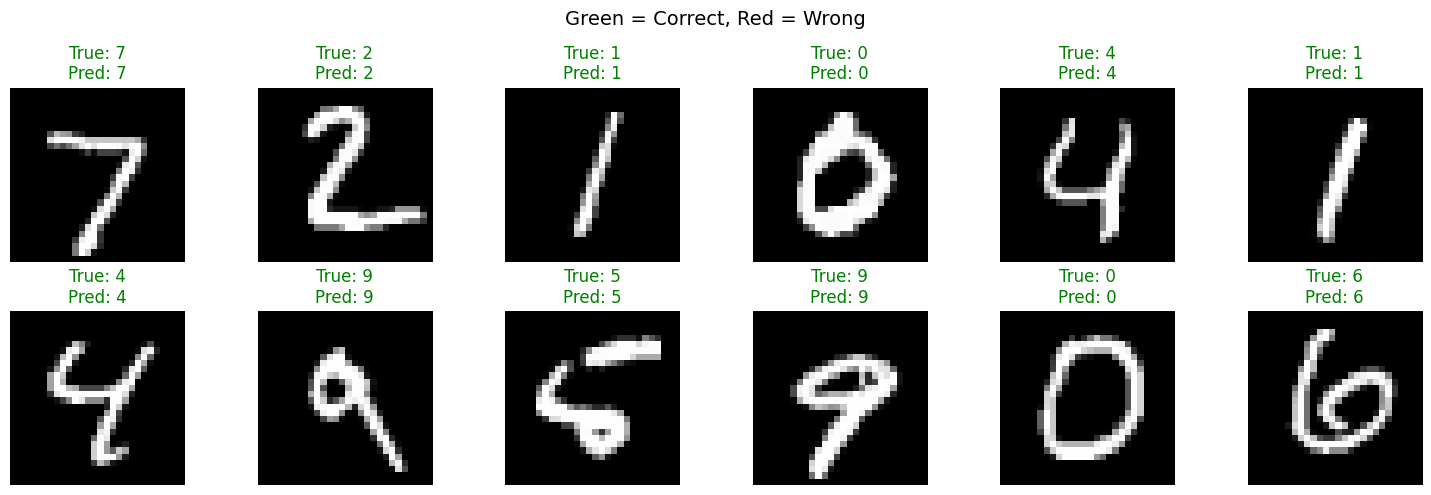

In [6]:
# Visualize predictions vs actual labels
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)

# Plot first 12 images with predicted vs actual
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
axes = axes.flatten()

for i in range(12):
    img = images[i].cpu().squeeze()
    true_label = labels[i].cpu().item()
    pred_label = predicted[i].cpu().item()

    axes[i].imshow(img, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    axes[i].axis('off')

plt.suptitle('Green = Correct, Red = Wrong', fontsize=14)
plt.tight_layout()
plt.show()

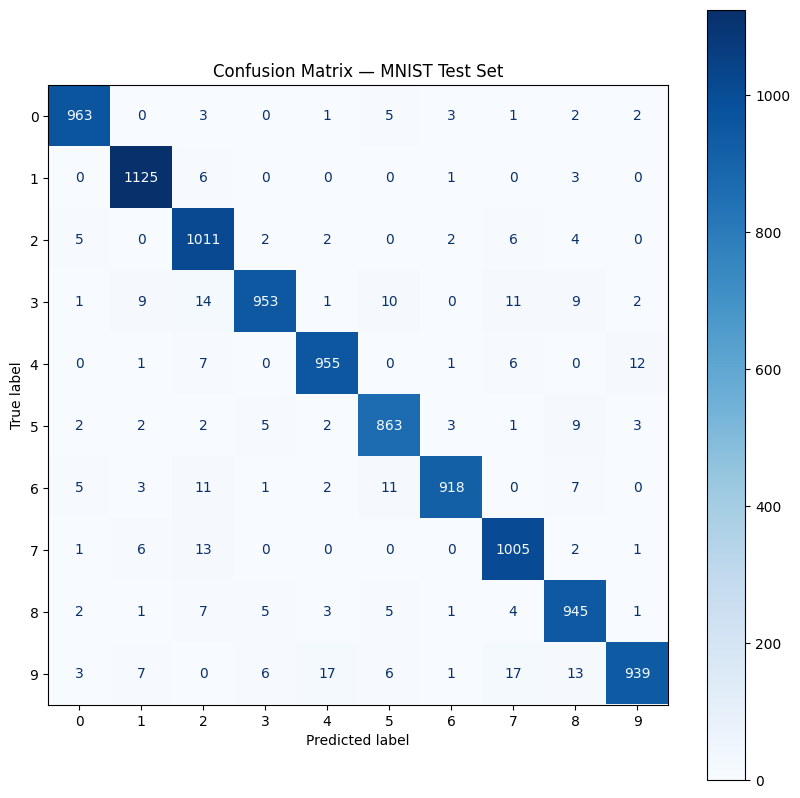

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix — MNIST Test Set')
plt.show()

In [8]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.network(x)

model = MNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
# Train with dropout, tracking loss per epoch
def train_with_history(model, loader, criterion, optimizer, epochs=5):
    model.train()
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        accuracy = 100 * correct / total
        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return loss_history

loss_history = train_with_history(model, train_loader, criterion, optimizer, epochs=5)
evaluate(model, test_loader, criterion)

Epoch 1/5 — Loss: 0.4868, Accuracy: 84.91%
Epoch 2/5 — Loss: 0.2519, Accuracy: 92.46%
Epoch 3/5 — Loss: 0.2052, Accuracy: 93.76%
Epoch 4/5 — Loss: 0.1830, Accuracy: 94.42%
Epoch 5/5 — Loss: 0.1678, Accuracy: 94.86%
Test Loss: 0.1152, Test Accuracy: 96.36%


96.36

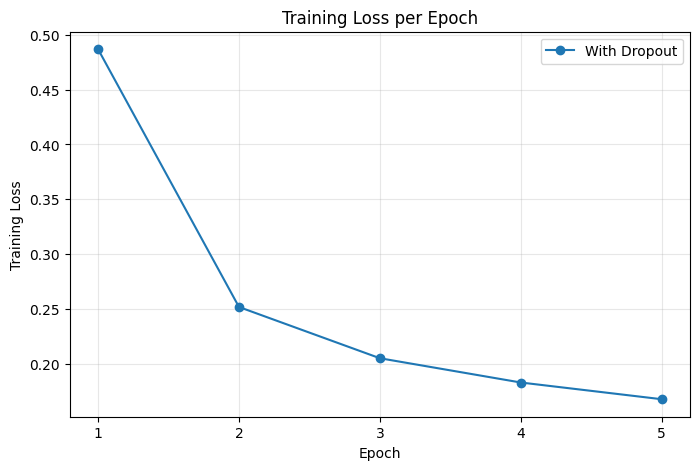

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', label='With Dropout')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss per Epoch')
plt.xticks(range(1, len(loss_history) + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [11]:
# Rebuild the ORIGINAL model (no dropout) for comparison
class MNISTNetOriginal(nn.Module):
    def __init__(self):
        super(MNISTNetOriginal, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.network(x)

model_original = MNISTNetOriginal().to(device)
criterion_original = nn.CrossEntropyLoss()
optimizer_original = optim.Adam(model_original.parameters(), lr=0.001)

loss_history_original = train_with_history(model_original, train_loader, criterion_original, optimizer_original, epochs=5)
evaluate(model_original, test_loader, criterion_original)

Epoch 1/5 — Loss: 0.3876, Accuracy: 88.46%
Epoch 2/5 — Loss: 0.1876, Accuracy: 94.24%
Epoch 3/5 — Loss: 0.1321, Accuracy: 95.91%
Epoch 4/5 — Loss: 0.1062, Accuracy: 96.68%
Epoch 5/5 — Loss: 0.0924, Accuracy: 97.14%
Test Loss: 0.1055, Test Accuracy: 96.83%


96.83

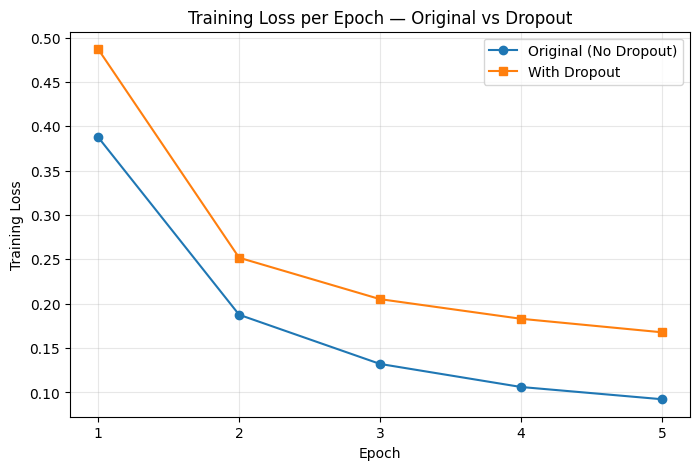

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history_original) + 1), loss_history_original, marker='o', label='Original (No Dropout)')
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='s', label='With Dropout')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss per Epoch — Original vs Dropout')
plt.xticks(range(1, len(loss_history) + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [13]:
# Save the original model's weights
torch.save(model_original.state_dict(), 'mnist_model.pth')
print("Model saved as mnist_model.pth")

Model saved as mnist_model.pth


In [14]:
# Load it back into a new model instance to verify
model_loaded = MNISTNetOriginal().to(device)
model_loaded.load_state_dict(torch.load('mnist_model.pth'))
model_loaded.eval()

print("Verifying loaded model matches original performance:")
evaluate(model_loaded, test_loader, criterion_original)

Verifying loaded model matches original performance:
Test Loss: 0.1055, Test Accuracy: 96.83%


96.83